## Анализ пользовательских предпочтений и популярности событий осенью 2024 года сервиса Яндекс Афиша. Проверка гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

- Автор: Голещихина О.К.
- Дата: 30.06.2026

### Цели и задачи проекта

Целью проекта является выявление инсайтов об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверка гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

Задачи: проведение исследовательского анализа данных, в том числе анализ фактора сезонности и изменения аудитории, выявление популярных событий, организаторов и площадок; проведение статистического расчета для проверки гипотезы (отличаются ли своей активностью пользователи мобильных устройств от клиентов, которые бронируют билеты со стационарного компьютера) и анализ результатов теста.

### Описание данных

Данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года.
Датасеты `final_tickets_orders_df.csv`, `final_tickets_events_df.csv` и `final_tickets_tenge_df.csv`.

Датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета:

****

Датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Поля датасета:

****

Датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Поля датасета:

****

### Содержимое проекта
<br>
    
1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Статистический анализ данных
5. Аналитическая записка
</font>

---

## Загрузка данных и знакомство с ними

Загрузим данные из файлов `final_tickets_orders_df.csv`, `final_tickets_events_df.csv` и `final_tickets_tenge_df.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
orders_df = pd.read_csv()
events_df = pd.read_csv()
tenge_df = pd.read_csv()

Выведем первые строки таблиц:

In [3]:
display(orders_df.head())
display(events_df.head())
display(tenge_df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Выведем общие данные по таблицам:

In [4]:
print(orders_df.info())
print(events_df.info())
print(tenge_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Все датасеты соответствуют описанию. Пропуски присутствуют только в столбце `days_since_prev` таблицы `final_tickets_orders_df.csv`, что также соответствует описанию (`days_since_prev - количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск`). Для дальнейшей работы необходимо изменить тип данных  в столбцах: `created_dt_msk`, `created_ts_msk` - таблицы `final_tickets_orders_df.csv`; `data` - таблицы `final_tickets_tenge_df.csv`.

## Предобработка данных

Скорректируем тип данных в столбцах с датой и временем.

In [5]:
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk'])
orders_df['created_ts_msk'] = pd.to_datetime(orders_df['created_ts_msk'])
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

В целях упрощения работы объединим таблицы в одну.

In [6]:
df = pd.merge(orders_df, events_df, how='left', on='event_id')
df = pd.merge(df, tenge_df, how='left', left_on='created_dt_msk', right_on='data')

Проверим датафрейм после объединения таблиц.

In [7]:
display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.6972,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.3419,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,100,19.6475,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,100,18.5010,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,100,19.6648,kzt


Для оптимизации работы снизим размерность количественных данных.

In [8]:
cols_int = ['order_id', 'event_id', 'age_limit', 'tickets_count', 'nominal'] #определяем столбцы с целочисленными данными
df[cols_int] = df[cols_int].apply(pd.to_numeric, downcast='integer')

cols_float = ['revenue', 'total', 'days_since_prev', 'city_id', 'venue_id', 'curs'] #определяем столбцы с данными с плавающей точкой
df[cols_float] = df[cols_float].apply(pd.to_numeric, downcast='float')

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int32         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int32         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int8          
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float32       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int8          
 12  total                   290849

После объединения таблиц в столбцах присоедененной таблицы `final_tickets_events_df.csv` появились пропуски. Скорее всего это связано с отсутствием идентификатора события по заказам, проверим это.

In [10]:
df_no_event = df.loc[df['event_name'].isna()]['event_id'].unique().tolist()
print(df_no_event, len(df_no_event))

[533222, 530296, 532300, 477731, 536716, 246804, 536731, 555671, 548224, 538260, 534151, 536715, 539336, 553041, 553435, 548062, 572020, 559840, 505937] 19


К 19 уникальным идентификаторам нет описания событий. Эти данные придется исключить из анализа, так как их определение имеет значение для дальнейшего анализа.

In [11]:
df = df.loc[~df['event_name'].isna()]

In [12]:
print(f'Количество удаленных строк: {orders_df.shape[0]-df.shape[0]} или {round((orders_df.shape[0]-df.shape[0])/orders_df.shape[0]*100,2)}%')

Количество удаленных строк: 238 или 0.08%


Количество удаленных строк составило менее 0.1%. 

Проверим какие числа содержит столбец с пропусками `days_since_prev`.

In [13]:
print(sorted(df['days_since_prev'].unique()))

[nan, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 137.0, 138.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0, 146.0, 147.0, 148.0]


Пропуски пока заменять не будем, при дальнейшей работе в зависимости от задачи возможно скорректируем.

Проверим остались ли еще пропуски в других столбцах после удаления строк.

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290848
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int32         
 1   user_id                 290611 non-null  object        
 2   created_dt_msk          290611 non-null  datetime64[ns]
 3   created_ts_msk          290611 non-null  datetime64[ns]
 4   event_id                290611 non-null  int32         
 5   cinema_circuit          290611 non-null  object        
 6   age_limit               290611 non-null  int8          
 7   currency_code           290611 non-null  object        
 8   device_type_canonical   290611 non-null  object        
 9   revenue                 290611 non-null  float32       
 10  service_name            290611 non-null  object        
 11  tickets_count           290611 non-null  int8          
 12  total                   290611

Остальные столбцы не содержат пропуски.

Проверим на неявные дубликаты столбцы `'cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 'event_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address', 'cdx'`.

In [15]:
for column in ['cinema_circuit','currency_code','device_type_canonical', 'service_name', 'event_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address', 'cdx']:
        print(f'Уникальные значения в столбце {column}:')
        print(df[column].sort_values().unique())
        print()

Уникальные значения в столбце cinema_circuit:
['Другое' 'КиноСити' 'Киномакс' 'Москино' 'ЦентрФильм' 'нет']

Уникальные значения в столбце currency_code:
['kzt' 'rub']

Уникальные значения в столбце device_type_canonical:
['desktop' 'mobile']

Уникальные значения в столбце service_name:
['Crazy ticket!' 'Show_ticket' 'Билет по телефону' 'Билеты без проблем'
 'Билеты в интернете' 'Билеты в руки' 'Быстробилет' 'Быстрый кассир'
 'Весь в билетах' 'Восьмёрка' 'Вперёд!' 'Выступления.ру'
 'Городской дом культуры' 'Дом культуры' 'Дырокол' 'За билетом!'
 'Зе Бест!' 'КарандашРУ' 'Кино билет' 'Край билетов' 'Лимоны'
 'Лови билет!' 'Лучшие билеты' 'Мир касс' 'Мой билет' 'Облачко'
 'Прачечная' 'Радио ticket' 'Реестр' 'Росбилет' 'Тебе билет!' 'Телебилет'
 'Тех билет' 'Цвет и билет' 'Шоу начинается!' 'Яблоко']

Уникальные значения в столбце event_name:
['000a9c8d-65bb-4178-a5a8-9ddc1f3bf71e'
 '0015b11d-a3e0-4656-887a-383450a9b313'
 '00298e1a-ae90-482b-819d-ba88ceff59b0' ...
 'fff20f2b-de72-451a-8168-

['алл. 1 Мая, д. 3/4 стр. 4/5' 'алл. 1 Мая, д. 32 стр. 46'
 'алл. 40 лет Октября, д. 1' ... 'ш. Южное, д. 807'
 'ш. Ярославское, д. 1 к. 8/9' 'ш. Ярославское, д. 6/8']

Уникальные значения в столбце cdx:
['kzt']



Визуальный анализ показал, что в столбце `event_type_description` возможно наличие неявных дубликатов (например, 'спорт' и
'спортивное мероприятие'). Учтем этот факт при проверке на явные дубликаты (исключим столбец при проверке). При анализе остальных столбцов отклонений не выявлено.

Проверим столбец `order_id` - является ли он ключом или нет. 

In [16]:
print(df['order_id'].nunique())

290611


Количество уникальных заказов соответствует количеству строк, соответственно столбец `order_id` - является ключом.

Проверим полные дубликаты исключив столбцы `order_id`, `event_type_description`.

In [17]:
cols_to_check = df.columns.drop(['order_id', 'event_type_description'])
duplicates = df[df.duplicated(subset=cols_to_check, keep=False)]
duplicates_sorted = duplicates.sort_values(by='user_id')
with pd.option_context('display.max_columns', None):
    display(duplicates_sorted)
print(duplicates_sorted.shape)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.820000,Билеты в руки,1,997.479980,0.0,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",2024-08-13,100,18.855301,kzt
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.820000,Билеты в руки,1,997.479980,0.0,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",2024-08-13,100,18.855301,kzt
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.230000,Лови билет!,2,280.809998,0.0,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39",2024-10-30,100,19.951599,kzt
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.230000,Лови билет!,2,280.809998,0.0,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39",2024-10-30,100,19.951599,kzt
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.189999,Билеты в руки,3,739.849976,0.0,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76.0,3094.0,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2",2024-06-25,100,18.801201,kzt
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.189999,Билеты в руки,3,739.849976,0.0,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76.0,3094.0,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2",2024-06-25,100,18.801201,kzt
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.959999,Лучшие билеты,4,674.119995,0.0,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21.0,2155.0,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432",2024-10-28,100,19.926600,kzt
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.959999,Лучшие билеты,4,674.119995,0.0,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21.0,2155.0,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432",2024-10-28,100,19.926600,kzt
156213,6657937,7eb4fc207ecc10f,2024-10-26,2024-10-26 09:39:03,418836,нет,0,rub,mobile,294.850006,Лови билет!,3,4914.209961,0.0,a4478837-4631-4e28-95d7-a4c26751a232,цирковое шоу,другое,№1703,Тепляковская область,Горнодолинск,43.0,4481.0,"Школа сценического мастерства ""Вдох"" Лтд","пер. Полярный, д. 87",2024-10-26,100,19.926600,kzt
154993,3463819,7eb4fc207ecc10f,2024-09-21,2024-09-21 11:43:58,448579,нет,0,rub,mobile,2.540000,Лови билет!,1,84.820000,0.0,a751c430-d352-44d7-99a0-29e97193eba5,спорт,спорт,№1622,Североярская область,Озёрск,2.0,4607.0,"Команда артистов ""Светлячок"" Лимитед","пер. Невского, д. 72",2024-09-21,100,19.331600,kzt


(58, 28)


Обнаружено 58 дубликатов.

Cтолбец `event_type_description` не влияет на возникновение дубликатов. Вероятнее всего дубликаты связаны с техническим сбоем, так как разница только в номере заказа. Исключим данное дублирование, оставив первые строки.

In [18]:
df_clear = df.drop_duplicates(subset=cols_to_check, keep='first').copy()
display(df_clear.head())
print(f'Количество строк после удаления дубликатов: {df_clear.shape[0]}')

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.697201,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.450012,...,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.341900,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,...,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,100,19.647499,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.490000,...,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,100,18.500999,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,...,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,100,19.664801,kzt


Количество строк после удаления дубликатов: 290581


In [19]:
print(f'Количество удаленных строк к исходному датасету: {df.shape[0]-df_clear.shape[0]} или {round((df.shape[0]-df_clear.shape[0])/orders_df.shape[0]*100,2)}%')

Количество удаленных строк к исходному датасету: 30 или 0.01%


Выведем статистические данные по столбам `'age_limit', 'revenue', 'tickets_count', 'total', 'curs'`.

In [20]:
display(df_clear[['age_limit', 'revenue', 'tickets_count', 'total', 'curs']].describe().T)

,count,mean,std,min,25%,50%,75%,max
age_limit,290581.0,10.207488,6.518451,0.000000,6.000000,12.000000,16.000000,18.000000
revenue,290581.0,625.610474,1227.680054,-90.760002,116.849998,356.019989,810.130005,81174.539062
tickets_count,290581.0,2.754337,1.170614,1.000000,2.000000,3.000000,4.000000,57.000000
total,290581.0,7532.633789,15333.395508,-358.850006,2160.070068,4775.020020,8955.950195,811745.375000
curs,290581.0,19.188309,0.622535,17.848600,18.599100,19.325600,19.788401,20.277300


В данных столбцах `revenue`, `tickets_count` возможно наличие выбросов. Проверим это применив диаграмму размаха - "ящик с усами".

В первую очередь проведем анализ по столбцу `revenue`. Так как в столбце присутствуют два типа валюты приведем сначала значение выручки к единой системе и создадим столбец `revenue_rub`, который и будем анализировать.

In [21]:
df_clear['revenue_rub'] = df_clear['revenue']
df_clear.loc[df_clear['currency_code']=='kzt', 'revenue_rub'] = df_clear.loc[df_clear['currency_code']=='kzt', 'revenue']/df_clear.loc[df_clear['currency_code']=='kzt', 'nominal']*df_clear.loc[df_clear['currency_code']=='kzt', 'curs']

In [22]:
display(df_clear.loc[df_clear['currency_code']=='kzt'].head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx,revenue_rub
73,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.099976,...,Серебрянка,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-09-17,100,19.012501,kzt,98.503761
92,8634925,0040e12d70fae81,2024-09-02,2024-09-02 19:49:14,559476,нет,6,kzt,desktop,347.179993,...,Серебрянка,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-09-02,100,18.933001,kzt,65.731590
99,7625522,0054b38b2653e6e,2024-09-09,2024-09-09 18:06:04,559582,нет,6,kzt,mobile,328.769989,...,Серебрянка,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",2024-09-09,100,18.599100,kzt,61.148262
289,720419,00f4f5244501ce6,2024-06-11,2024-06-11 20:15:57,536826,нет,12,kzt,mobile,22021.550781,...,Серебрянка,163.0,2066.0,"Архитектурное бюро ""Секрет"" Инк","пер. Проточный, д. 70 к. 881",2024-06-11,100,19.892799,kzt,4380.703125
472,5227657,01370a0e9c1a7d5,2024-06-04,2024-06-04 13:28:17,533803,нет,16,kzt,desktop,7397.660156,...,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",2024-06-04,100,19.983299,kzt,1478.296509


Выведем статистические данные нового столбца и построим диаграмму размаха.

In [23]:
print(df_clear['revenue_rub'].describe())

count    290581.000000
mean        555.591431
std         875.487671
min         -90.760002
25%         113.970001
50%         351.140015
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64


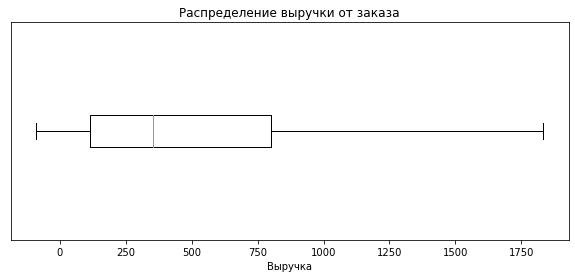

In [24]:
plt.figure(figsize=(10, 4))

plt.boxplot(df_clear['revenue_rub'], showfliers=False, vert=False)
plt.title('Распределение выручки от заказа')
plt.xlabel('Выручка')
plt.yticks([])
plt.show()

Построим этот же график с учетом "выбросов".

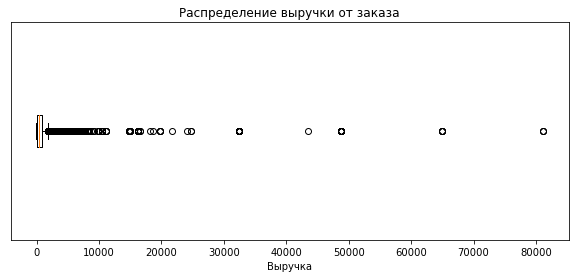

In [25]:
plt.figure(figsize=(10, 4))

plt.boxplot(df_clear['revenue_rub'], vert=False)
plt.title('Распределение выручки от заказа')
plt.xlabel('Выручка')
plt.yticks([])
plt.show()

В данных присутствуют выбросы. Для дальнейшей работы отфильтруем данные по 99 процентилю.

In [26]:
df_clear_rev = df_clear.loc[df_clear['revenue_rub']<=df_clear['revenue_rub'].quantile(0.99)].copy()

In [27]:
print(f'Количество удаленных строк к исходному датасету: {df_clear.shape[0]-df_clear_rev.shape[0]} или {round((df_clear.shape[0]-df_clear_rev.shape[0])/orders_df.shape[0]*100,2)}%')

Количество удаленных строк к исходному датасету: 2825 или 0.97%


In [28]:
print(df_clear_rev['revenue_rub'].describe())

count    287756.000000
mean        518.047607
std         511.979279
min         -90.760002
25%         111.860001
50%         343.955002
75%         788.659973
max        2628.421631
Name: revenue_rub, dtype: float64


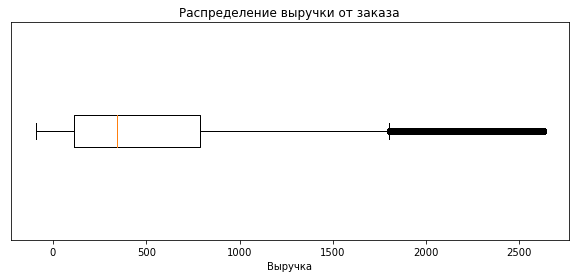

In [29]:
plt.figure(figsize=(10, 4))

plt.boxplot(df_clear_rev['revenue_rub'], vert=False)
plt.title('Распределение выручки от заказа')
plt.xlabel('Выручка')
plt.yticks([])
plt.show()

Также в данных по выручке наблюдаются отрицательные значения. Такие показатели могут возникнуть, например, при проведении акций или похожих мероприятий. Поэтому минимальные значения по столбцу корректировать не будем.

Проверим выбросы в столбце `tickets_count`.

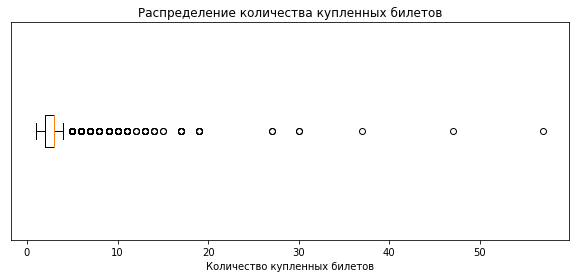

In [30]:
plt.figure(figsize=(10, 4))

plt.boxplot(df_clear_rev['tickets_count'], vert=False)
plt.title('Распределение количества купленных билетов')
plt.xlabel('Количество купленных билетов')
plt.yticks([])
plt.show()

В столбце присутствуют аномально высокие значения по количеству купленных билетов. Максимальное значение соотвествует 57. Данные оставим как есть.

Для дальнейшего исследования создадим дополнительные столбцы: `one_ticket_revenue_rub` - выручка с продажи одного билета на мероприятие; `month` - месяц оформления заказа; `season` - информация о сезонности ('лето', 'осень', 'зима', 'весна').

In [31]:
df_clear_rev['one_ticket_revenue_rub'] = df_clear_rev['revenue_rub']/df_clear_rev['tickets_count']
df_clear_rev['month'] = df_clear_rev['created_dt_msk'].dt.month
df_clear_rev['season'] = 'лето'
df_clear_rev.loc[df_clear_rev['month'].isin([12, 1, 2]), 'season'] = 'зима'
df_clear_rev.loc[df_clear_rev['month'].isin([3, 4, 5]), 'season'] = 'весна'
df_clear_rev.loc[df_clear_rev['month'].isin([9, 10, 11]), 'season'] = 'осень'

Проверим итоговую таблицу на корректность.

In [32]:
display(df_clear_rev.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_name,venue_address,data,nominal,curs,cdx,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.697201,kzt,1521.939941,380.484985,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.450012,...,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.341900,kzt,289.450012,144.725006,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,...,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,100,19.647499,kzt,1258.569946,314.642487,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.490000,...,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,100,18.500999,kzt,8.490000,4.245000,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,...,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,100,19.664801,kzt,1390.410034,463.470001,10,осень


In [33]:
print(df_clear_rev.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287756 entries, 0 to 290848
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287756 non-null  int32         
 1   user_id                 287756 non-null  object        
 2   created_dt_msk          287756 non-null  datetime64[ns]
 3   created_ts_msk          287756 non-null  datetime64[ns]
 4   event_id                287756 non-null  int32         
 5   cinema_circuit          287756 non-null  object        
 6   age_limit               287756 non-null  int8          
 7   currency_code           287756 non-null  object        
 8   device_type_canonical   287756 non-null  object        
 9   revenue                 287756 non-null  float32       
 10  service_name            287756 non-null  object        
 11  tickets_count           287756 non-null  int8          
 12  total                   287756

In [34]:
print(f'Количество удаленных строк к исходному датасету: {orders_df.shape[0]-df_clear_rev.shape[0]} или {round((orders_df.shape[0]-df_clear_rev.shape[0])/orders_df.shape[0]*100,2)}%')

Количество удаленных строк к исходному датасету: 3093 или 1.06%


В ходе предобработки данных таблицы были объеденены в одну, типы данных, содержащие дату и время (столбцы `created_dt_msk`, `created_ts_msk`, `data`) были преобразованы к корректному формату. Из итогового датафрейма были удалены 3093 строк (1.06%), в том числе 238 строк или 0.08% по причине отстутствия описания событий по уникальным идентификаторам; 30 строк или 0.01% - дубликаты; 2825 строк или 0.97% - фильтрция данных по 99 процентилю столбца `revenue_rub` (выручка от заказа в рублях). Дополнительно были созданы столбцы `one_ticket_revenue_rub` - выручка с продажи одного билета на мероприятие; `month` - месяц оформления заказа; `season` - информация о сезонности ('лето', 'осень', 'зима', 'весна').

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

**Выведем динамику количества заказов для каждого месяца в разрезе типа мероприятия `event_type_main`, типa устройства `device_type_canonical`, категории мероприятий по возрастному рейтингу `age_limit`.**

In [35]:
order_count_event = pd.pivot_table(df_clear_rev, index='event_type_main', columns='month', values='order_id', aggfunc='count')
print('Распределение количества заказов по типу мероприятий по месяцам')
display(order_count_event)

Распределение количества заказов по типу мероприятий по месяцам


month,6,7,8,9,10
event_type_main,,,,,
выставки,614,1017,785,847,1589
другое,8864,11469,12036,14556,18669
концерты,15219,16803,18536,25006,37899
спорт,261,714,2031,7974,10907
стендап,1517,2145,2686,3047,3877
театр,7362,8237,8359,17643,25119
ёлки,66,67,140,342,1353


Визуализируем динамику количества заказов на линейном графике.

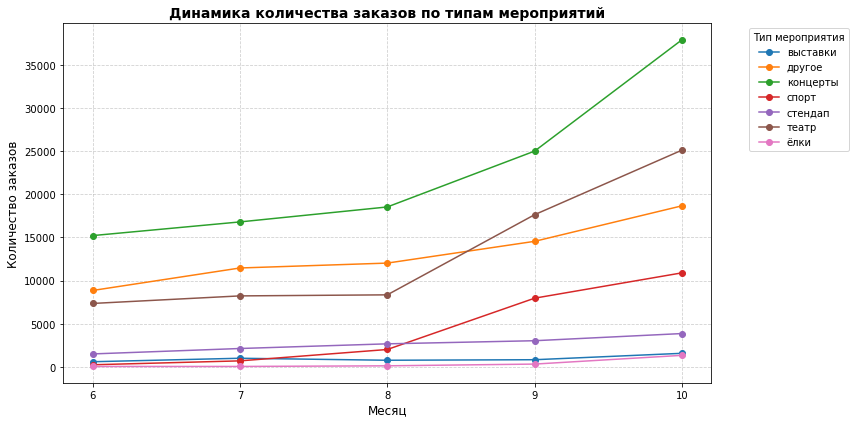

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(order_count_event.T, marker='o')

plt.title('Динамика количества заказов по типам мероприятий', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(order_count_event.index, title='Тип мероприятия', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(order_count_event.columns)

plt.tight_layout()
plt.show()

In [37]:
order_count_device = pd.pivot_table(df_clear_rev, index='device_type_canonical', columns='month', values='order_id', aggfunc='count')
print('Распределение количества заказов по типу устройств по месяцам')
display(order_count_device)

Распределение количества заказов по типу устройств по месяцам


month,6,7,8,9,10
device_type_canonical,,,,,
desktop,6747,7909,8305,13405,20951
mobile,27156,32543,36268,56010,78462


Визуализируем динамику количества заказов на линейном графике.

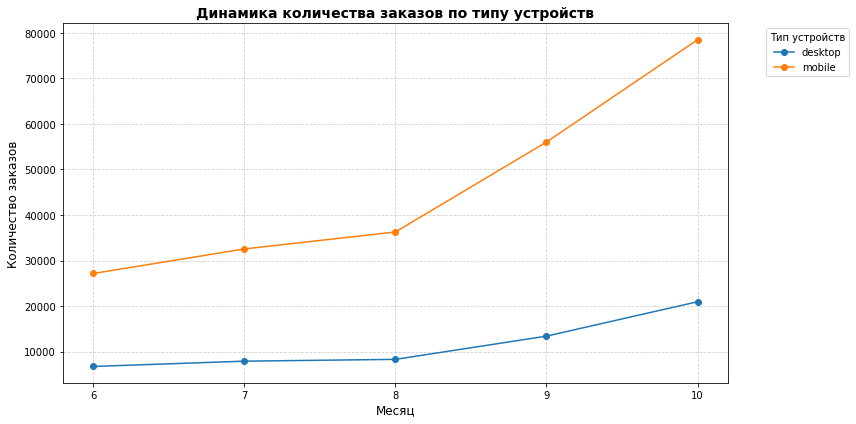

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(order_count_device.T, marker='o')

plt.title('Динамика количества заказов по типу устройств', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(order_count_device.index, title='Тип устройств', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(order_count_device.columns)

plt.tight_layout()
plt.show()

In [39]:
order_count_age = pd.pivot_table(df_clear_rev, index='age_limit', columns='month', values='order_id', aggfunc='count')
print('Распределение количества заказов по возрастному ограничению по месяцам')
display(order_count_age)

Распределение количества заказов по возрастному ограничению по месяцам


month,6,7,8,9,10
age_limit,,,,,
0,5636,6560,9208,15922,23911
6,6029,7871,7869,12841,17034
12,7744,7647,8770,15838,21446
16,9889,11780,12099,17661,26565
18,4605,6594,6627,7153,10457


Визуализируем динамику количества заказов на линейном графике.

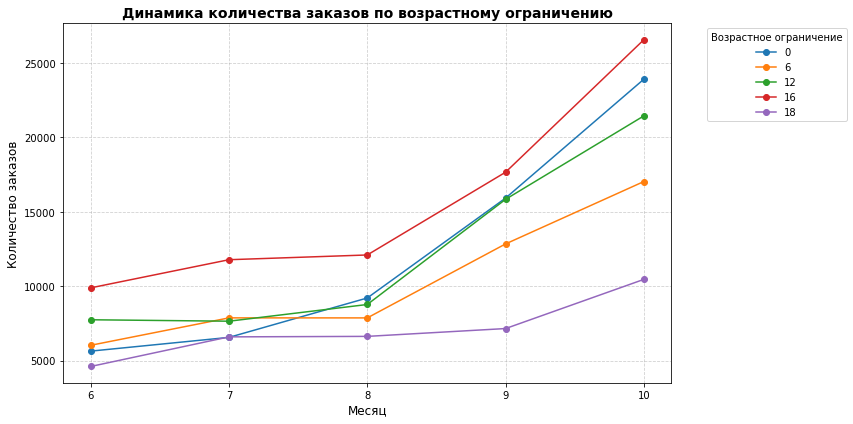

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(order_count_age.T, marker='o')

plt.title('Динамика количества заказов по возрастному ограничению', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(order_count_age.index, title='Возрастное ограничение', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(order_count_age.columns)

plt.tight_layout()
plt.show()

Динамика количества заказов по исследуемым сегментам увеличивается от июня к ноябрю 2024г.

**Для осеннего и летнего периодов сравним распределение заказов билетов по сегментам: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу.**

In [41]:
season_count_event = pd.pivot_table(df_clear_rev, index='event_type_main', columns='season', values='order_id', aggfunc='count')
season_event = season_count_event.div(season_count_event.sum(axis=0), axis=1)
season_event = round(season_event, 2)
print('Распределение доли заказов по типу мероприятий по периоду')
display(season_event)

Распределение доли заказов по типу мероприятий по периоду


season,лето,осень
event_type_main,,
выставки,0.02,0.01
другое,0.27,0.20
концерты,0.43,0.37
спорт,0.03,0.11
стендап,0.05,0.04
театр,0.20,0.25
ёлки,0.00,0.01


Визуализируем изменение доли заказов по типу мероприятий по сезону, используя столбчатую диаграмму.

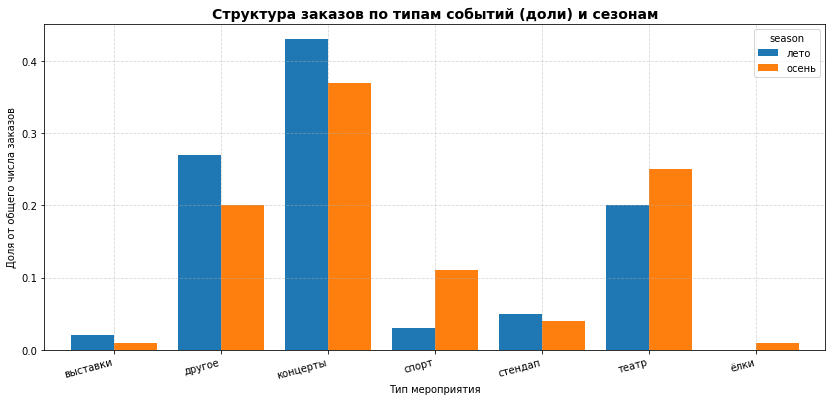

In [42]:
seasons = ['лето', 'осень']
plot_data = season_event[seasons]

ax = plot_data.plot(kind='bar', figsize=(14, 6), width=0.8, grid=True)

ax.set_title('Структура заказов по типам событий (доли) и сезонам', fontsize=14, fontweight='bold')
ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Доля от общего числа заказов')
ax.grid(linestyle='--', alpha=0.5)
ax.set_xticklabels(plot_data.index, rotation=15, ha='right')

plt.show()

In [43]:
season_count_device = pd.pivot_table(df_clear_rev, index='device_type_canonical', columns='season', values='order_id', aggfunc='count')
season_device = season_count_device.div(season_count_device.sum(axis=0), axis=1)
season_device = round(season_device, 2)
print('Распределение доли заказов по типу устройств по периоду')
display(season_device)

Распределение доли заказов по типу устройств по периоду


season,лето,осень
device_type_canonical,,
desktop,0.19,0.2
mobile,0.81,0.8


Визуализируем изменение доли заказов по типу устройств по сезону, используя столбчатую диаграмму.

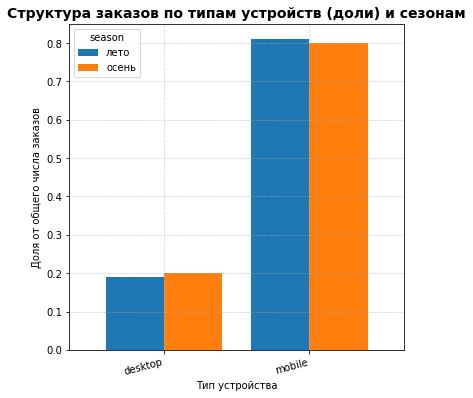

In [44]:
seasons = ['лето', 'осень']
plot_data = season_device[seasons]

ax = plot_data.plot(kind='bar', figsize=(6, 6), width=0.8, grid=True)

ax.set_title('Структура заказов по типам устройств (доли) и сезонам', fontsize=14, fontweight='bold')
ax.set_xlabel('Тип устройства')
ax.set_ylabel('Доля от общего числа заказов')
ax.grid(linestyle='--', alpha=0.5)
ax.set_xticklabels(plot_data.index, rotation=15, ha='right')

plt.show()

In [45]:
season_count_age = pd.pivot_table(df_clear_rev, index='age_limit', columns='season', values='order_id', aggfunc='count')
season_age = season_count_age.div(season_count_age.sum(axis=0), axis=1)
season_age = round(season_age, 2)
print('Распределение доли заказов по возрастному ограничению по периоду')
display(season_age)

Распределение доли заказов по возрастному ограничению по периоду


season,лето,осень
age_limit,,
0,0.18,0.24
6,0.18,0.18
12,0.20,0.22
16,0.28,0.26
18,0.15,0.10


Визуализируем изменение доли заказов по возрастному ограничению по сезону, используя столбчатую диаграмму.

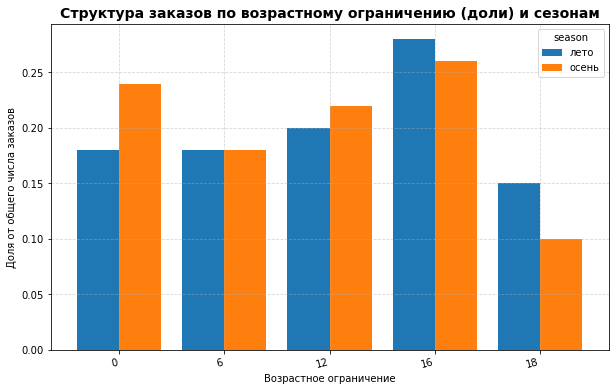

In [46]:
seasons = ['лето', 'осень']
plot_data = season_age[seasons]

ax = plot_data.plot(kind='bar', figsize=(10, 6), width=0.8, grid=True)

ax.set_title('Структура заказов по возрастному ограничению (доли) и сезонам', fontsize=14, fontweight='bold')
ax.set_xlabel('Возрастное ограничение')
ax.set_ylabel('Доля от общего числа заказов')
ax.grid(linestyle='--', alpha=0.5)
ax.set_xticklabels(plot_data.index, rotation=15, ha='right')

plt.show()

Анализ распределения доли заказов по исследуемым сегментам показал некоторые колебания. Наиболее заметный сдвиг наблюдается по сегменту - тип мероприятий. Возможно, что сезонность имеет значение в выборе типа события. *По структуре возврастного ограничения осенью наиболее существенный сдвиг наблюдается в категории "0+" в сторону увеличения заказов.*

**Выведем изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.**

In [47]:
season_rev_event = pd.pivot_table(df_clear_rev, index='event_type_main', columns='season', values='one_ticket_revenue_rub', aggfunc='mean')
season_rev_event['отклонение, абс'] = season_rev_event['осень']-season_rev_event['лето']
season_rev_event['отклонение, %'] = (season_rev_event['осень']-season_rev_event['лето'])/season_rev_event['лето']*100
print('Средняя выручка с продажи одного билета')
display(season_rev_event.style.format("{:.2f}"))

Средняя выручка с продажи одного билета


season,лето,осень,"отклонение, абс","отклонение, %"
event_type_main,,,,
выставки,86.42,90.60,4.19,4.85
другое,77.43,76.12,-1.32,-1.70
концерты,302.35,269.32,-33.03,-10.92
спорт,50.76,49.97,-0.79,-1.56
стендап,218.59,231.47,12.88,5.89
театр,214.40,176.23,-38.17,-17.80
ёлки,271.44,230.31,-41.13,-15.15


Визуализируем среднюю выручку по типам мероприятий в зависимости от сезона. Используем столбчатую диаграмму.

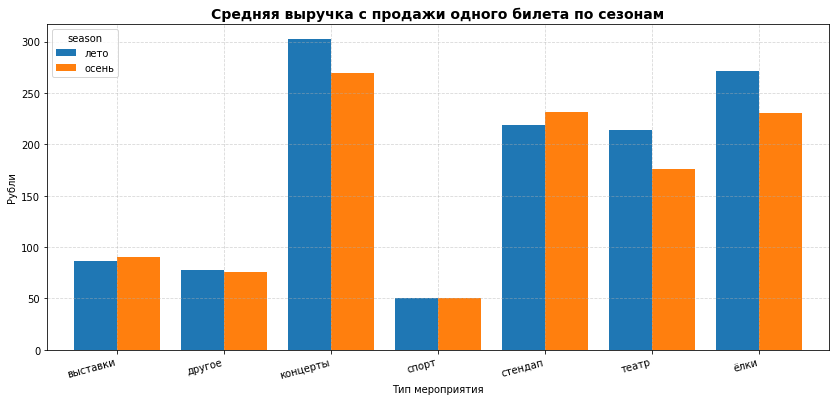

In [48]:
seasons = ['лето', 'осень']
plot_data = season_rev_event[seasons]

ax = plot_data.plot(kind='bar', figsize=(14, 6), width=0.8, grid=True)

ax.set_title('Средняя выручка с продажи одного билета по сезонам', fontsize=14, fontweight='bold')
ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Рубли')
ax.grid(linestyle='--', alpha=0.5)
ax.set_xticklabels(plot_data.index, rotation=15, ha='right')

plt.show()

Дополнительно визуализируем относительное изменение средней выручки по типам мероприятий в зависимости от сезона (осень к лету).

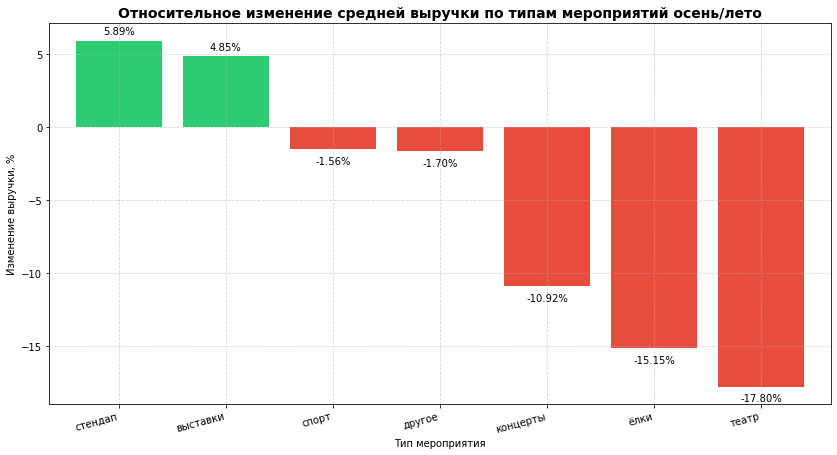

In [49]:
plot_data = season_rev_event['отклонение, %'].sort_values(ascending=False)

colors = ["#2ecc71" if val >= 0 else "#e74c3c" for val in plot_data]

ax = plot_data.plot(kind='bar', figsize=(14, 7), width=0.8, grid=True, color=colors)

for p in ax.patches:
    height = p.get_height()
    va_dir = "bottom" if height >= 0 else "top"
    offset = 4 if height >= 0 else -7
    ax.annotate(f"{height:.2f}%", (p.get_x() + p.get_width() / 2.0, height), ha="center", va=va_dir, xytext=(0, offset),
        textcoords="offset points", fontsize=10)
ax.set_title('Относительное изменение средней выручки по типам мероприятий осень/лето', fontsize=14, fontweight='bold')
ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Изменение выручки, %')
ax.grid(linestyle='--', alpha=0.5)
ax.set_xticklabels(plot_data.index, rotation=15, ha='right')

plt.show()

Средняя выручка с наступлением осени больше всего изменилась (снизилась) по трем типам мероприятий: театр (снижение на 17.8%), елки (снижение на 15.15%), концерты (снижение на 10.92%).

### Анализ осенней активности пользователей

**Проанализируем динамику изменений активности по дням.**

In [50]:
#Фильтруем данные по сезону
df_autumn = df_clear_rev.loc[df_clear_rev['season']=='осень'].copy()
#Создаем сводную таблицу и считаем статистику по дням (количество заказов, DAU, среднее число заказов на пользователя)
day_activity = pd.pivot_table(df_autumn, index='created_dt_msk', values=['order_id', 'user_id'], aggfunc={'order_id':'count', 'user_id':'nunique'})
day_activity.columns = ['count_orders', 'dau']
day_activity['avg_order_per_user'] = round(day_activity['count_orders']/day_activity['dau'],2)
#Создаем столбец с общей суммой заказа в рублях (переводим kzt в rub)
df_autumn['total_rub'] = df_autumn['total']
df_autumn.loc[df_autumn['currency_code']=='kzt', 'total_rub'] = df_autumn.loc[df_autumn['currency_code']=='kzt', 'total']/df_autumn.loc[df_autumn['currency_code']=='kzt', 'nominal']*df_autumn.loc[df_autumn['currency_code']=='kzt', 'curs']
#Создаем сводную таблицу и считаем статистику по дням показателя средней стоимости одного билета
avg_cost = pd.pivot_table(df_autumn, index='created_dt_msk', values=['tickets_count', 'total_rub'], aggfunc={'tickets_count':'sum', 'total_rub':'sum'})
avg_cost['avg_cost_per_ticket'] = round(avg_cost['total_rub']/avg_cost['tickets_count'],2)
#Добавляем столбец к итоговой таблице
day_activity['avg_cost_per_ticket'] = avg_cost['avg_cost_per_ticket']
display(day_activity.head())

,count_orders,dau,avg_order_per_user,avg_cost_per_ticket
created_dt_msk,,,,
2024-09-01,1331,565,2.36,2266.94
2024-09-02,1380,574,2.40,2208.84
2024-09-03,5114,778,6.57,1261.47
2024-09-04,1774,686,2.59,2170.35
2024-09-05,1945,740,2.63,2213.48


Визуализируем полученные результаты в линейных графиках.

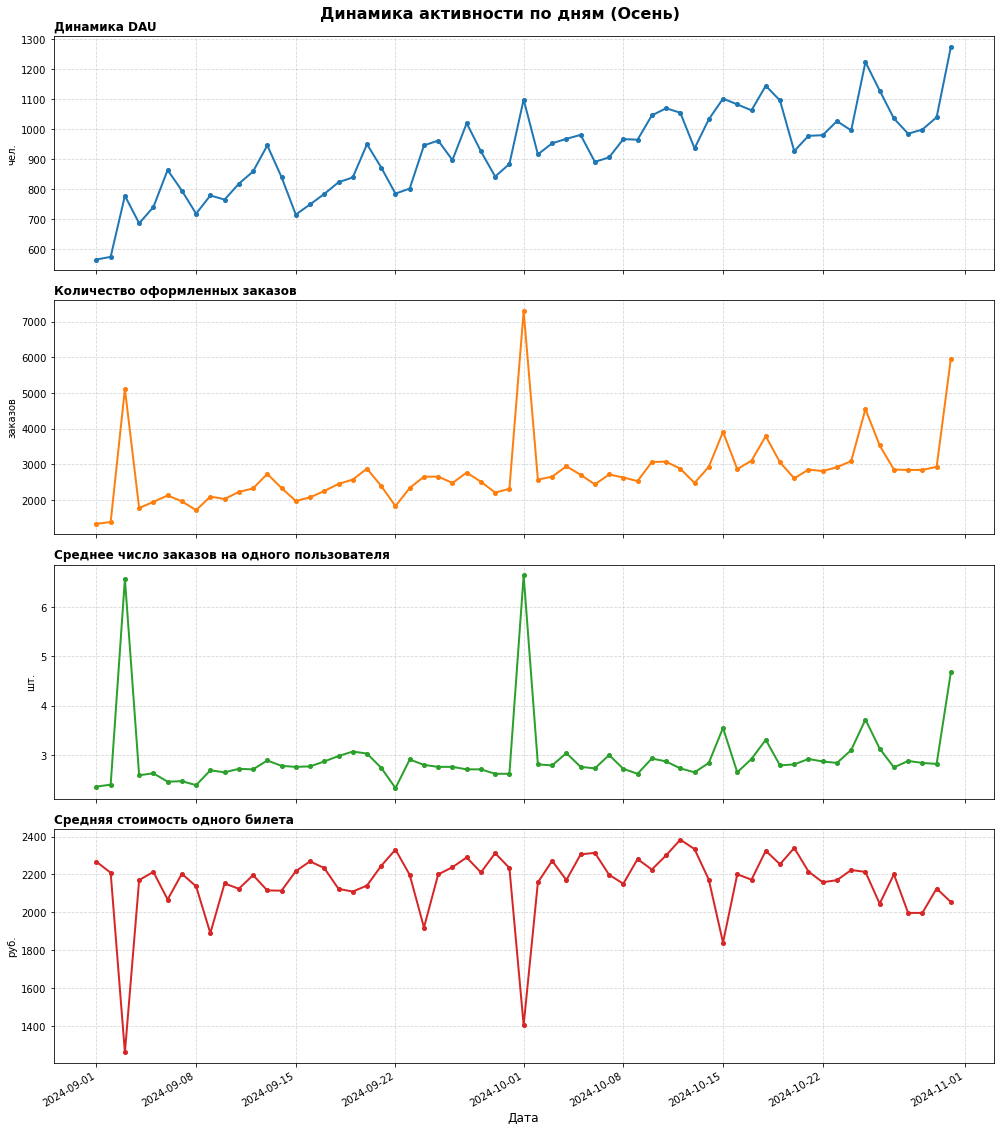

In [51]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

metrics = [
    ("dau", "Динамика DAU", "#1f77b4", "чел."),
    ("count_orders", "Количество оформленных заказов","#ff7f0e", "заказов"),
    ("avg_order_per_user", "Среднее число заказов на одного пользователя", "#2ca02c", "шт."),
    ("avg_cost_per_ticket", "Средняя стоимость одного билета", "#d62728","руб.")]

for ax, (col_name, title, color, unit) in zip(axes, metrics):
    ax.plot(day_activity.index, day_activity[col_name], color=color, linewidth=2, marker="o", markersize=4)
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left")
    ax.set_ylabel(unit, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=30, ha="right")
axes[-1].set_xlabel("Дата", fontsize=12)

plt.suptitle("Динамика активности по дням (Осень)", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

График динамики DAU показывает рост полльзователей с начала рассматриваемого периода к концу (с 565 чел. до почти 1300 чел. в день). По показателям: количество оформленных заказов и среднее число оформленных заказов на одного пользователя - выявляются всплески активности. В это же время при росте этих показателей видим снижение показателя средней стоимости одного билета. *Всплески активности при падении средней стоимости могут свидетельствовать о проведении каких-либо акций или распродаж.* 

Проверим зависимость активности от дня недели.

In [52]:
#Добавим столбец с днями недели
day_activity['day_of_week'] = day_activity.index.day_of_week+1
day_of_week = {1:'Пн', 2:'Вт', 3:'Ср', 4:'Чт', 5:'Пт', 6:'Сб', 7:'Вс'}
day_activity['day_of_week'] = day_activity['day_of_week'].map(day_of_week)
#Сформируем таблицу с средними значениями показателей в зависимости от дня недели
week_activity = pd.pivot_table(day_activity, index='day_of_week', values=['count_orders', 'dau', 'avg_order_per_user', 'avg_cost_per_ticket'], aggfunc='mean')
week_activity = round(week_activity, 2)
days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
week_activity = week_activity.reindex(days)
display(week_activity)

,avg_cost_per_ticket,avg_order_per_user,count_orders,dau
day_of_week,,,,
Пн,2153.65,2.78,2392.78,854.44
Вт,1902.23,3.72,3503.67,935.56
Ср,2172.78,2.75,2546.33,924.44
Чт,2189.46,3.07,3021.89,963.11
Пт,2203.00,3.00,3107.38,1023.38
Сб,2220.31,2.76,2670.25,961.75
Вс,2272.60,2.60,2158.33,823.89


Визуализируем статистики в зависимости от дней недели, используем линейные графики.

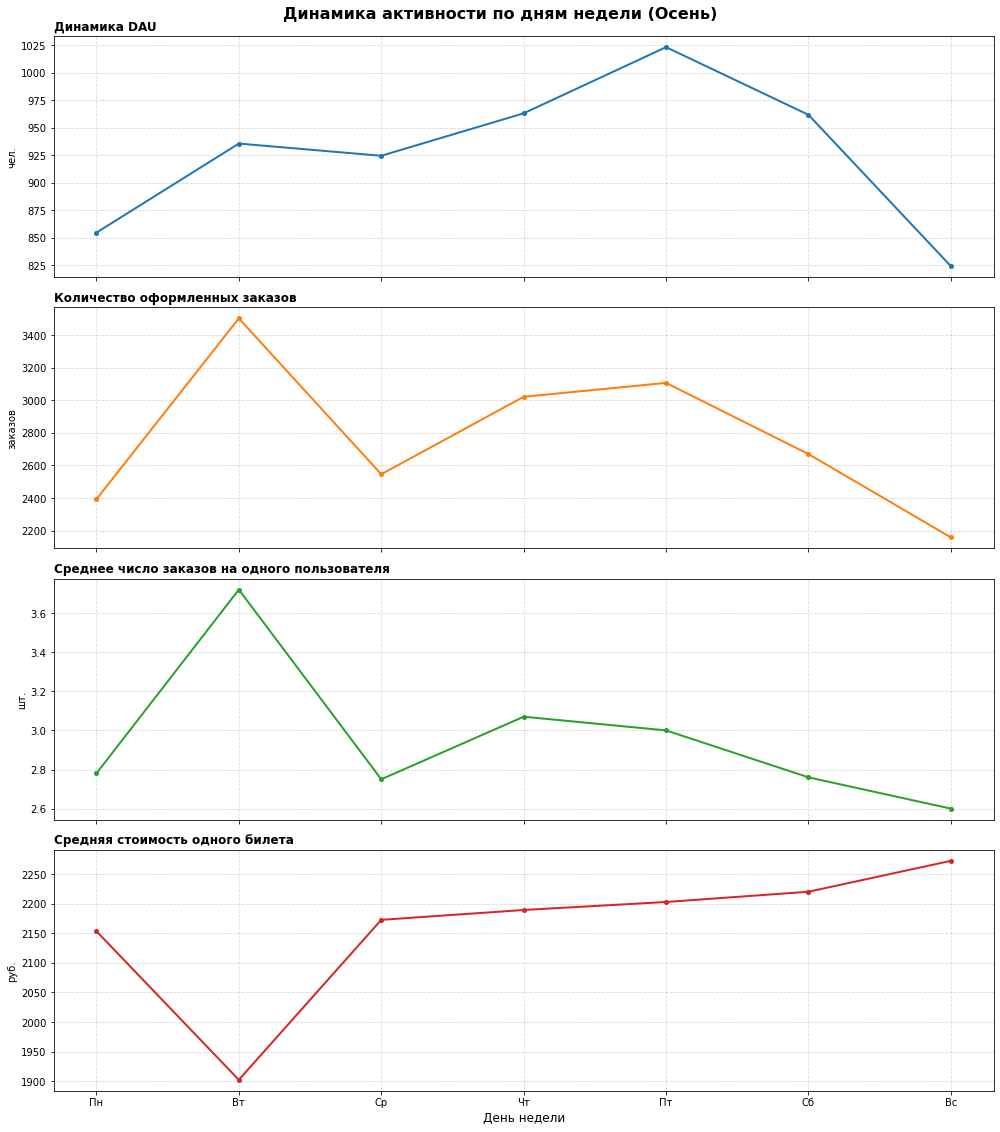

In [53]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

metrics = [
    ("dau", "Динамика DAU", "#1f77b4", "чел."),
    ("count_orders", "Количество оформленных заказов","#ff7f0e", "заказов"),
    ("avg_order_per_user", "Среднее число заказов на одного пользователя", "#2ca02c", "шт."),
    ("avg_cost_per_ticket", "Средняя стоимость одного билета", "#d62728","руб.")]

for ax, (col_name, title, color, unit) in zip(axes, metrics):
    ax.plot(week_activity.index, week_activity[col_name], color=color, linewidth=2, marker="o", markersize=4)
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left")
    ax.set_ylabel(unit, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("День недели", fontsize=12)

plt.suptitle("Динамика активности по дням недели (Осень)", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

По полученным графикам видим, что активность в выходные дни ниже, чем в будни (падает количество активных пользователей, общее количество заказов и среднее число заказов на пользователя). При снижении этих показателей, однако, повышается средняя стоимость одного билета.

### Популярные события и партнёры

**Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов.** 

In [54]:
region_stat = pd.pivot_table(df_clear_rev, index='region_name', values=['event_type_description', 'order_id'], aggfunc={'event_type_description':'nunique', 'order_id':'count'})
region_stat = region_stat.sort_values(by='event_type_description', ascending=False)
event_type_description_count = df_clear_rev['event_type_description'].nunique()#считаем общее количество уникальных типов мероприятий
order_id_count = df_clear_rev['order_id'].nunique()#считаем общее количество уникальных заказов
region_stat['event_type_description_per'] = round(region_stat['event_type_description']/event_type_description_count*100, 2)
region_stat['orders_per'] = round(region_stat['order_id']/order_id_count*100, 2)
display(region_stat.head(15))

,event_type_description,order_id,event_type_description_per,orders_per
region_name,,,,
Широковская область,17,16172,85.0,5.62
Каменевский регион,17,89749,85.0,31.19
Светополянский округ,14,7502,70.0,2.61
Медовская область,13,13893,65.0,4.83
Горицветская область,13,5154,65.0,1.79
Североярская область,13,43752,65.0,15.20
Речиновская область,12,6268,60.0,2.18
Серебринская область,12,5591,60.0,1.94
Зоринский регион,12,3207,60.0,1.11


Выведем диаграмму ТОП-15 регионов с наибольшим количеством типов мероприятий.

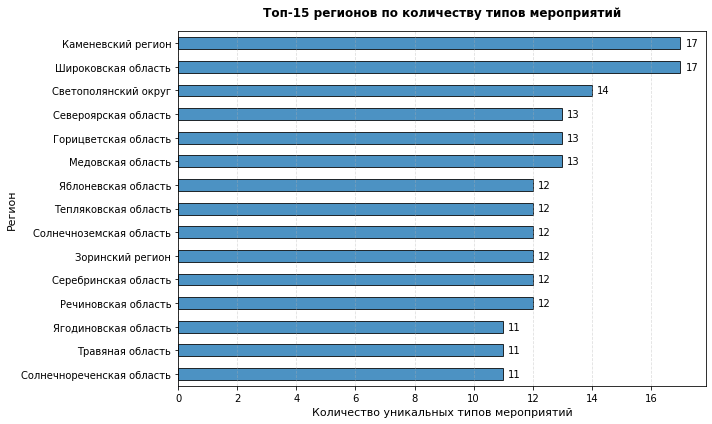

In [55]:
plt.figure(figsize=(10, 6))

plot_data = region_stat.head(15).sort_values(by='event_type_description', ascending=True)
plot_data['event_type_description'].plot(kind="barh", color="#1f77b4", edgecolor="black", alpha=0.8)

[plt.bar_label(container, fmt="%.0f", padding=5, fontsize=10) for container in plt.gca().containers]

plt.title("Топ-15 регионов по количеству типов мероприятий", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Количество уникальных типов мероприятий", fontsize=11)
plt.ylabel("Регион", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Наибольшее разнообразие меропирятий представлено в 2-х регионах: Каменевский регион и Широковская область. В них представлено по 17 типов мероприятий, что соотвествует 85% от общего количества типов мероприятий. Однако, при таком разнообразии доля числа заказов в общем количестве в Каменевском регионе составляет 31%, а в Широковской области всего 6%.

**Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов.**

In [56]:
service_name_stat = pd.pivot_table(df_clear_rev, index='service_name', values=['event_type_description', 'order_id', 'revenue_rub'], aggfunc={'event_type_description':'nunique', 'order_id':'count', 'revenue_rub':'sum'})
service_name_stat['revenue_rub'] = service_name_stat['revenue_rub']*0.001#Переведем данные в тыс.руб.
service_name_stat = service_name_stat.sort_values(by='order_id', ascending=False)
#Считаем суммарное количество заказов и сумарную выручку
order_total_count = service_name_stat['order_id'].sum()
revenue_rub_total = service_name_stat['revenue_rub'].sum()
#Считаем % заказов и % выручки по билетным партнерам в общем количестве
service_name_stat['orders_per'] = service_name_stat['order_id']/order_total_count*100
service_name_stat['revenue_per'] = service_name_stat['revenue_rub']/revenue_rub_total*100
service_name_stat = round(service_name_stat, 2)
display(service_name_stat.head(15))

,event_type_description,order_id,revenue_rub,orders_per,revenue_per
service_name,,,,,
Билеты без проблем,13,63064,24856.580078,21.92,16.67
Лови билет!,13,40823,16729.890625,14.19,11.22
Билеты в руки,13,40284,13202.169922,14.00,8.86
Мой билет,12,34139,21062.109375,11.86,14.13
Облачко,11,26410,18609.300781,9.18,12.48
Лучшие билеты,9,17741,2724.060059,6.17,1.83
Весь в билетах,11,16438,16566.880859,5.71,11.11
Прачечная,16,10222,4746.810059,3.55,3.18
Край билетов,8,6118,6429.180176,2.13,4.31


Выведем диаграмму ТОП-15 наиблее активных билетных партнёра с наибольшим количеством заказов.

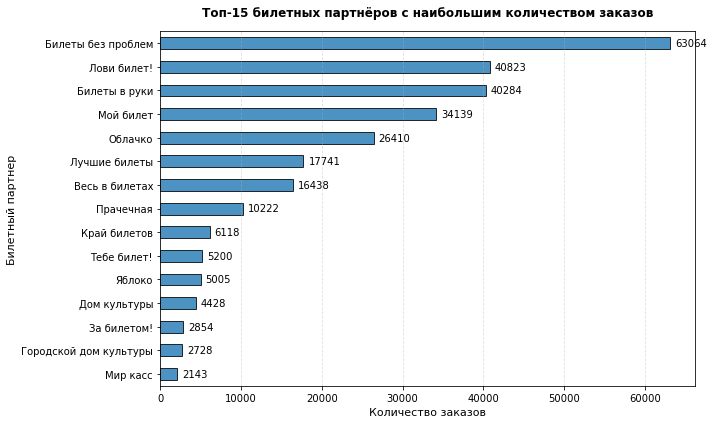

In [57]:
plt.figure(figsize=(10, 6))

plot_data = service_name_stat.head(15).sort_values(by='order_id', ascending=True)
plot_data['order_id'].plot(kind="barh", color="#1f77b4", edgecolor="black", alpha=0.8)

[plt.bar_label(container, fmt="%.0f", padding=5, fontsize=10) for container in plt.gca().containers]

plt.title("Топ-15 билетных партнёров с наибольшим количеством заказов", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Количество заказов", fontsize=11)
plt.ylabel("Билетный партнер", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Посчитаем какой процент заказов и выручки приходится на ТОП-15 билетных партнеров.

In [58]:
service_name_stat_15 = service_name_stat.head(15)
print(f"На ТОП-15 билетных партнеров приходится {service_name_stat_15['orders_per'].sum():.2f}% всех заказов.")
print(f"На ТОП-15 билетных партнеров приходится {service_name_stat_15['revenue_per'].sum():.2f}% всей выручки.")

На ТОП-15 билетных партнеров приходится 96.48% всех заказов.
На ТОП-15 билетных партнеров приходится 95.05% всей выручки.


Наиболее активным билетным партнером является "Билеты без проблем". На этого опретора приходтся 63064 заказов (21.92%) от общего числа. Соответственно у этого оператора и наибольший процент выручки - 16.67% от всей выручки за период.

## Статистический анализ данных

Статистический анализ будем проводить за осенний период. Для этого используем ранее отфильтрованный датафрейм по заданному периоду `df_autumn`.

**Первая гипотеза звучит так: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.**

Попробуем статистически это доказать, используем одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Среднее количество заказов на одного пользователя мобильного приложения и стационарных устройств не различается.

- Альтернативная гипотеза H₁: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.

Для корретности анализа проверим независимость выборок и определим есть ли пользователи, совершившие заказы как с мобильного устройства, так и со стационарного.

In [59]:
user_device_type_canonical = df_autumn.groupby('user_id')['device_type_canonical'].nunique().sort_values(ascending=False).reset_index()
display(user_device_type_canonical.head())
print('Количество пользователей совершивших заказы как с мобильного устройства, так и со стационарного:')
print(user_device_type_canonical.loc[user_device_type_canonical['device_type_canonical']==2]['user_id'].count())
print('Общее количество пользователей:')
print(user_device_type_canonical['user_id'].nunique())
print('Доля пользователей, совершивших заказы как с мобильного устройства, так и со стационарного:')
print((user_device_type_canonical.loc[user_device_type_canonical['device_type_canonical']==2]['user_id'].count())/(user_device_type_canonical['user_id'].nunique()))

,user_id,device_type_canonical
0,4680bfb9e7b945c,2
1,6d12e4b036d5dab,2
2,332292961dd0f9e,2
3,3327703b0afd9d9,2
4,6d56430f78d06af,2


Количество пользователей совершивших заказы как с мобильного устройства, так и со стационарного:
3250
Общее количество пользователей:
15821
Доля пользователей, совершивших заказы как с мобильного устройства, так и со стационарного:
0.20542317173377156


В целях проверки гипотезы исключим из анализа пользователей, попавших в обе группы.

In [60]:
users_for_clear = user_device_type_canonical.loc[user_device_type_canonical['device_type_canonical']==2]['user_id'].tolist()
user_device_type_canonical_clear = df_autumn.loc[~df_autumn['user_id'].isin(users_for_clear)]
print('Общее количество пользователей для проверки гипотезы:')
print(user_device_type_canonical_clear['user_id'].nunique())

Общее количество пользователей для проверки гипотезы:
12571


Сгуппируем данные для статистического теста.

In [61]:
users_device_type = user_device_type_canonical_clear.groupby(['device_type_canonical', 'user_id'])['order_id'].count().reset_index()
display(users_device_type)

,device_type_canonical,user_id,order_id
0,desktop,0040e12d70fae81,1
1,desktop,006d1660d830822,7
2,desktop,00bdfa36a6e542b,1
3,desktop,00cb8c1ef996876,2
4,desktop,00e62ce48c12cb4,2
...,...,...,...
12566,mobile,ffe364dd8211157,3
12567,mobile,ffe73c50cbd71fc,2
12568,mobile,ffed3ff067d4f12,3
12569,mobile,fff13b79bd47d7c,3


Рассчитаем значение p_value для выбранной гипотезы, используя функции модуля scipy.stats и односторонний t-тест.

Дополнительно рассчитаем среднее количество заказов на одного пользователя мобильного приложения и среднее количество заказов на одного пользователя стационарного устройства.

In [69]:
user_mobile = users_device_type['order_id'].loc[users_device_type['device_type_canonical']=='mobile']
user_desktop = users_device_type['order_id'].loc[users_device_type['device_type_canonical']=='desktop']

results = st.ttest_ind(user_mobile, user_desktop, alternative='greater')
p_value = results.pvalue
if p_value < 0.05:
    print(f'Полученное значение {p_value=} меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.')
else:
    print(f'Полученное значение {p_value=} больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.')

mean_user_mobile = round(users_device_type['order_id'].loc[users_device_type['device_type_canonical']=='mobile'].mean())
mean_user_desktop = round(users_device_type['order_id'].loc[users_device_type['device_type_canonical']=='desktop'].mean())

print(f'Среднее количество заказов на одного пользователя мобильного приложения {mean_user_mobile}.')
print(f'Среднее количество заказов на одного пользователя стационарного устройства {mean_user_desktop}.')

Полученное значение p_value=1.8207925847952376e-17 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Среднее количество заказов на одного пользователя мобильного приложения 3.
Среднее количество заказов на одного пользователя стационарного устройства 2.


Гипотеза о том, что среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств подтвердилась. Нулевая гипотеза статистически опровергнута. 

**Вторая гипотеза: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.**

Для статистического анализа также используем одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Среднее время между заказами пользователей мобильного приложения и стационарных устройств не различается.

- Альтернативная гипотеза H₁: Среднее время между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.

Для анализа используем подготовленный датафрейм при проверке первой гипотезы `user_device_type_canonical_clear` (отфильтрованный по периоду "осень" и "очищенный" от пользователей, попавших в обе выборки - мобильных и стационарных устройств).
Создадим столбец, где расчитаем время между заказами пользователей (используем столбец с датой и временем `created_ts_msk`).

In [64]:
user_device_type_canonical_clear = user_device_type_canonical_clear.sort_values(by=['user_id', 'created_ts_msk'])#Сортируем датафрейм по пользователю и дате и времени
user_device_type_canonical_clear['time_to_prev_order'] = user_device_type_canonical_clear.groupby('user_id')['created_ts_msk'].diff()#Создаем новый столбец с расчетом интервала между заказами
#Переведем интервал в дни (с дробной частью)
user_device_type_canonical_clear['time_to_prev_order'] = user_device_type_canonical_clear['time_to_prev_order'].dt.total_seconds() / (24*3600)
display(user_device_type_canonical_clear.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,data,nominal,curs,cdx,revenue_rub,one_ticket_revenue_rub,month,season,total_rub,time_to_prev_order
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,...,2024-10-06,100,19.647499,kzt,1258.569946,314.642487,10,осень,13984.160156,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,...,2024-10-04,100,19.664801,kzt,1390.410034,463.470001,10,осень,10695.429688,NaN
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.739990,...,2024-10-23,100,20.053101,kzt,902.739990,300.913330,10,осень,8206.700195,18.693576
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.779999,...,2024-09-29,100,19.374100,kzt,47.779999,47.779999,9,осень,955.520020,NaN
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.839996,...,2024-10-15,100,19.718500,kzt,74.839996,37.419998,10,осень,2494.729980,15.617963


Рассчитаем значение p_value для выбранной гипотезы, используя функции модуля scipy.stats и односторонний t-тест.

Дополнительно рассчитаем среднее время между заказами пользователей мобильного приложения и стационарных устройств.

У каждого пользователя для его самого первого заказа в таблице значение NaN (пустота), так как предыдущего заказа еще не было.
Поэтому для корректности расчета статистического теста необходимо очистить срезы от пропусков с помощью метода .dropna() перед передачей в тест.

In [70]:
time_to_prev_mobile = user_device_type_canonical_clear.loc[user_device_type_canonical_clear['device_type_canonical']=='mobile', 'time_to_prev_order'].dropna()
time_to_prev_desktop = user_device_type_canonical_clear.loc[user_device_type_canonical_clear['device_type_canonical']=='desktop', 'time_to_prev_order'].dropna()

results = st.ttest_ind(time_to_prev_mobile, time_to_prev_desktop, alternative='greater')
p_value = results.pvalue
if p_value < 0.05:
    print(f'Полученное значение {p_value=} меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.')
else:
    print(f'Полученное значение {p_value=} больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.')

mean_time_to_prev_mobile = round(user_device_type_canonical_clear.loc[user_device_type_canonical_clear['device_type_canonical']=='mobile', 'time_to_prev_order'].mean())
mean_time_to_prev_desktop = round(user_device_type_canonical_clear.loc[user_device_type_canonical_clear['device_type_canonical']=='desktop', 'time_to_prev_order'].mean())

print(f'Среднее время между заказами пользователей мобильного приложения {mean_time_to_prev_mobile} дней.')
print(f'Среднее время между заказами пользователей стационарного устройства {mean_time_to_prev_desktop} дней.')

Полученное значение p_value=6.704014382199023e-19 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Среднее время между заказами пользователей мобильного приложения 5 дней.
Среднее время между заказами пользователей стационарного устройства 3 дней.


Гипотеза о том, что среднее время между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств подтвердилась. Нулевая гипотеза статистически опровергнута. 

## Аналитическая записка


В работе были использованы данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года, датасеты : 
- final_tickets_orders_df.csv (с информацией обо всех заказах билетов) 
- final_tickets_events_df.csv (с информацей о событиях)
- final_tickets_tenge_df.csv (с информацией о курсе тенге к российскому рублю за 2024 год)

В ходе предобработки данных были скорректированы типы данным у столбцов, содержащих информацию даты и времени (`created_dt_msk`, `created_ts_msk` - таблицы `final_tickets_orders_df.csv`; `data` - таблицы `final_tickets_tenge_df.csv`).
Также были удалены строки с отстутствующим описанием событий по уникальным идентификаторам, дубликаты и выбросы по показателю - выручка от заказа в рублях (общее количество удаленных строк составило 3093 строк, 1.06%). Дополнительно были созданы столбцы `one_ticket_revenue_rub` - выручка с продажи одного билета на мероприятие; `month` - месяц оформления заказа; `season` - информация о сезонности ('лето', 'осень', 'зима', 'весна').

Исследовательский анализ данных позволяет сделать следующие выводы:
- динамика количества заказов во всех сегментах (типа мероприятия, типa устройства, категории мероприятий по возрастному рейтингу) увеличивается от июня к ноябрю 2024г;
- динамика DAU показывает рост полльзователей в осенний период более чем в два раза (с 565 чел. до почти 1300 чел. в день). В это же время выявляются всплески активности - при росте количества оформленных заказов и среднего числа оформленных заказов на одного пользователя снижается показатель средней стоимости одного билета;
- динамика осенней активности в выходные дни ниже, чем в будни. При снижении общего количества заказов и среднего числа заказов на пользователя повышается средняя стоимость одного билета;
- наибольшее разнообразие меропирятий представлено в 2-х регионах: Каменевский регион и Широковская область (по 17 типов мероприятий, что соотвествует 85% от общего количества типов мероприятий, при доле числа заказов в общем количестве в Каменевском регионе - 31%, а в Широковской области - 6%);
- среди билетных партнеров выделяется "Билеты без проблем". На этого опретора приходтся 63064 заказов (21.92%) от общего числа. 

В ходе проведения статистических тестов по проверке гипотез об отличии активности пользователей мобильных устройств от клиентов, которые бронируют билеты со стационарного компьютера, результаты показали следующую статистику:
- среднее количество заказов на одного пользователя мобильного приложения статистически выше по сравнению с пользователями стационарных устройств;
- среднее время между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств.

Таким образом, пользователи мобильного приложения совершают больше заказов за всё время, но делают это реже (с более длинными интервалами), в то время как пользователи стационарных устройств покупают реже в общем объёме, но делают заказы более плотно друг к другу.

Это говорит о том, что LTV у пользователей мобильных устройств выше и более высокий коэффициент удержания, чем у пользователей стационарных устройств.

В качестве рекомендаций можно предложить рассмотреть варианты по стимулированию частоты заказов для мобильных приложений (акции, бонусы) и варианты перевода desktop-пользователей в мобильное приложение (для повышения коэффициента удержания).

Также в летний сезон можно предложить проведение дополнительных акций и стимулирующих мероприятий для повышения количества заказов.